# 📊 Telco Customer Churn - Exploratory Data Analysis (EDA)

**Objective**: Conduct comprehensive exploratory data analysis on the Telco Customer Churn dataset to understand features, distributions, missing values, and relationship with customer churn before machine learning pipeline development.

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
sys.path.insert(0, str(Path('../').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from app.model import (
    load_data,
    get_dataset_shape,
    get_column_names,
    get_data_types,
    get_summary_statistics,
    get_duplicate_count,
    get_unique_counts,
    get_missing_summary,
    get_target_distribution,
    get_feature_lists,
)

# Configure plotting style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Dataset Overview

In [2]:
# Load dataset via app module loader
df = load_data('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
shape = get_dataset_shape(df)
print(f"Dataset Shape: {shape[0]} rows, {shape[1]} columns")

[2026-08-07 23:40:09,033] [INFO] [churn_api]: Attempting to load dataset from: ..\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
[2026-08-07 23:40:09,097] [INFO] [churn_api]: Dataset successfully loaded. Shape: (7043, 21)
Dataset Shape: 7043 rows, 21 columns


In [8]:
print("=== Dataset Head ===")
display(df.head())

print("=== Dataset Tail ===")
display(df.tail())

=== Dataset Head ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


=== Dataset Tail ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


In [9]:
print("=== Dataset Information ===")
df.info()

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

In [10]:
print("=== Summary Statistics (Numerical & Categorical) ===")
display(get_summary_statistics(df))

=== Summary Statistics (Numerical & Categorical) ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


## 2. Missing Values & Duplicate Inspection

In [11]:
duplicates = get_duplicate_count(df)
print(f"Duplicate Rows: {duplicates}")

missing_df = get_missing_summary(df)
print("=== Missing Values Summary ===")
display(missing_df)

Duplicate Rows: 0
=== Missing Values Summary ===


,missing_count,missing_percentage
TotalCharges,11,0.16


## 3. Feature Lists & Target Distribution

In [12]:
cat_cols, num_cols = get_feature_lists(df)
print(f"Categorical Features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical Features ({len(num_cols)}): {num_cols}")

target_dist = get_target_distribution(df)
print("=== Churn Target Distribution ===")
for label, stats in target_dist.items():
    print(f"{label}: {stats['count']} ({stats['percentage']}%")

[2026-08-07 23:35:30,547] [INFO] [churn_api]: Features identified: 15 categorical, 4 numerical.
Categorical Features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical Features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
[2026-08-07 23:35:30,553] [INFO] [churn_api]: Target variable ('Churn') distribution: {'No': {'count': 5174, 'percentage': 73.46}, 'Yes': {'count': 1869, 'percentage': 26.54}}
=== Churn Target Distribution ===
No: 5174 (73.46%
Yes: 1869 (26.54%


C:\Users\rakes\AppData\Local\Temp\ipykernel_11028\3396831474.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette='Set2')


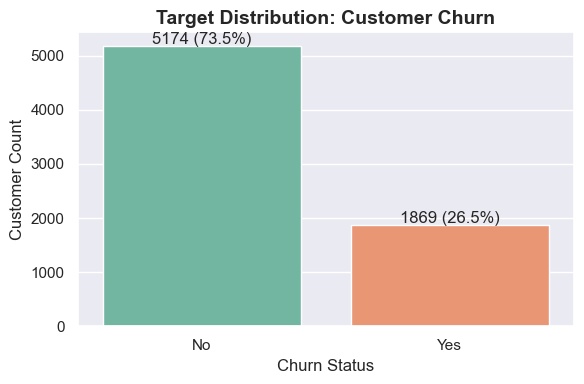

In [13]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Target Distribution: Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Customer Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

## 4. Numerical Features Analysis (Histograms & Boxplots)

C:\Users\rakes\AppData\Local\Temp\ipykernel_11028\3536366299.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 0], palette='Set2')
C:\Users\rakes\AppData\Local\Temp\ipykernel_11028\3536366299.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 1], palette='Set2')
C:\Users\rakes\AppData\Local\Temp\ipykernel_11028\3536366299.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1, 2], palette='Set2')


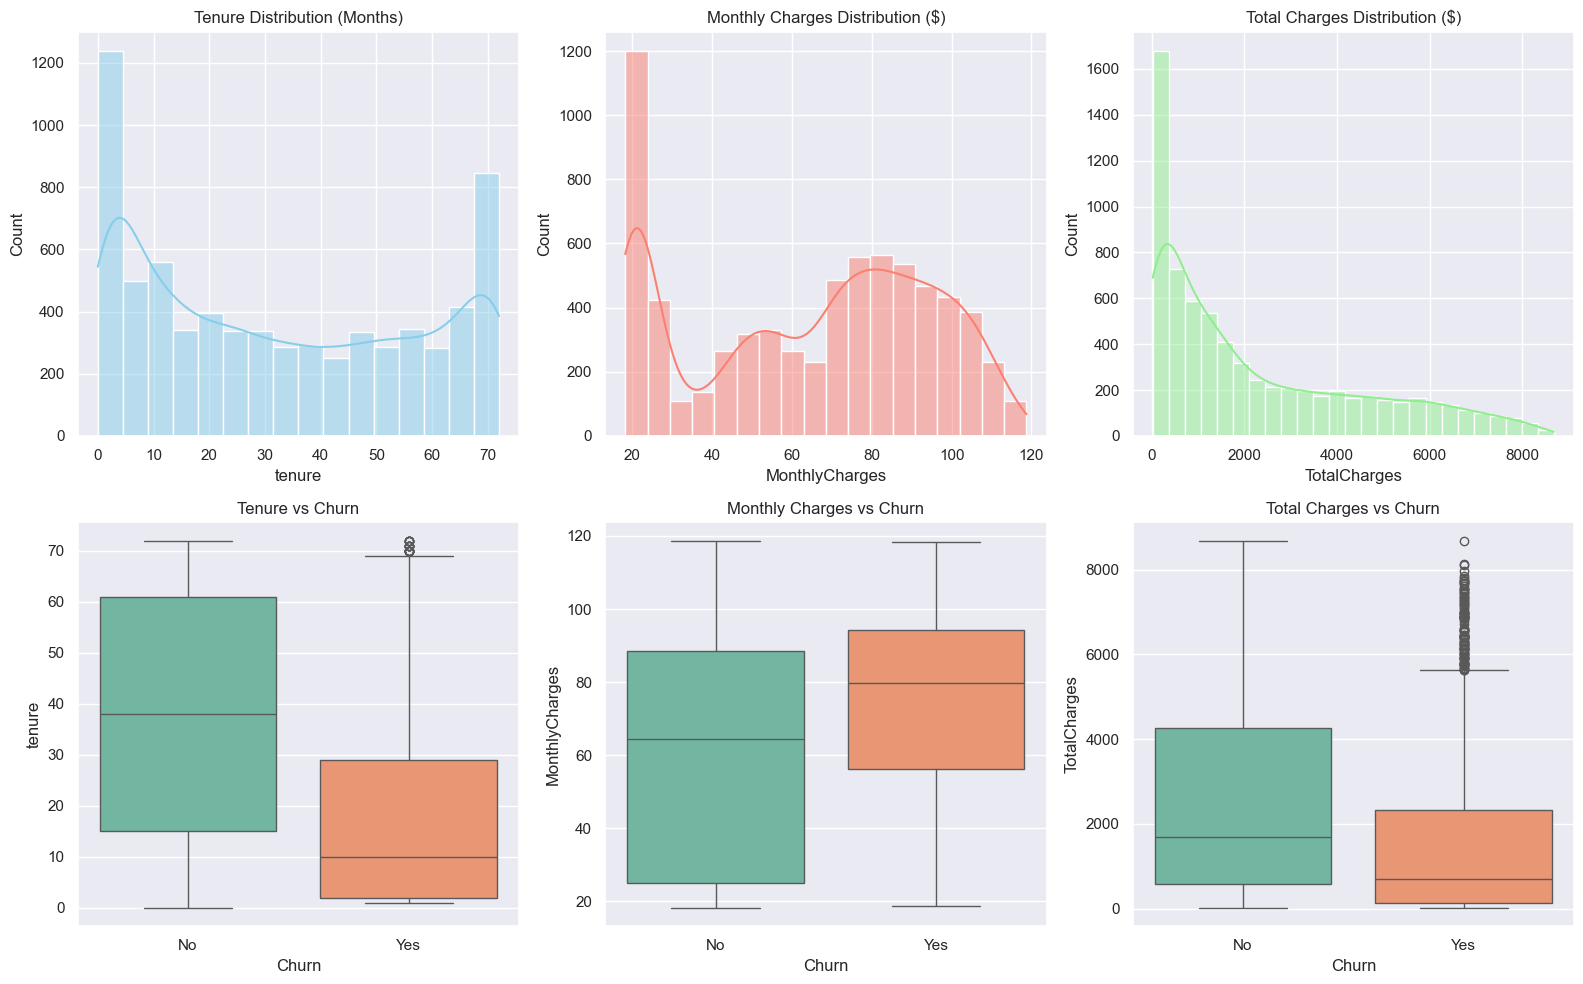

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Histograms
sns.histplot(df['tenure'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Tenure Distribution (Months)')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Monthly Charges Distribution ($)')

sns.histplot(df['TotalCharges'].dropna(), kde=True, ax=axes[0, 2], color='lightgreen')
axes[0, 2].set_title('Total Charges Distribution ($)')

# Boxplots vs Churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Tenure vs Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Monthly Charges vs Churn')

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Total Charges vs Churn')

plt.tight_layout()
plt.show()

## 5. Correlation Matrix (Numeric Features)

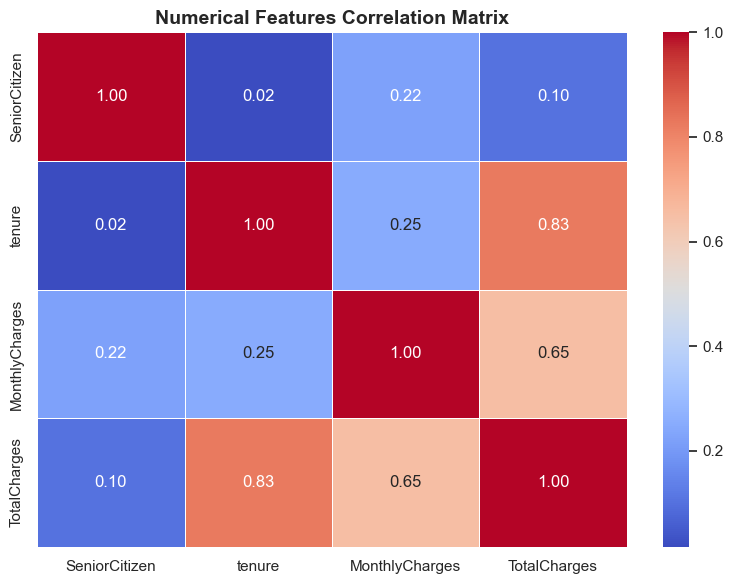

In [15]:
numeric_df = df[num_cols].copy()
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Numerical Features Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Categorical Features vs Churn Distribution

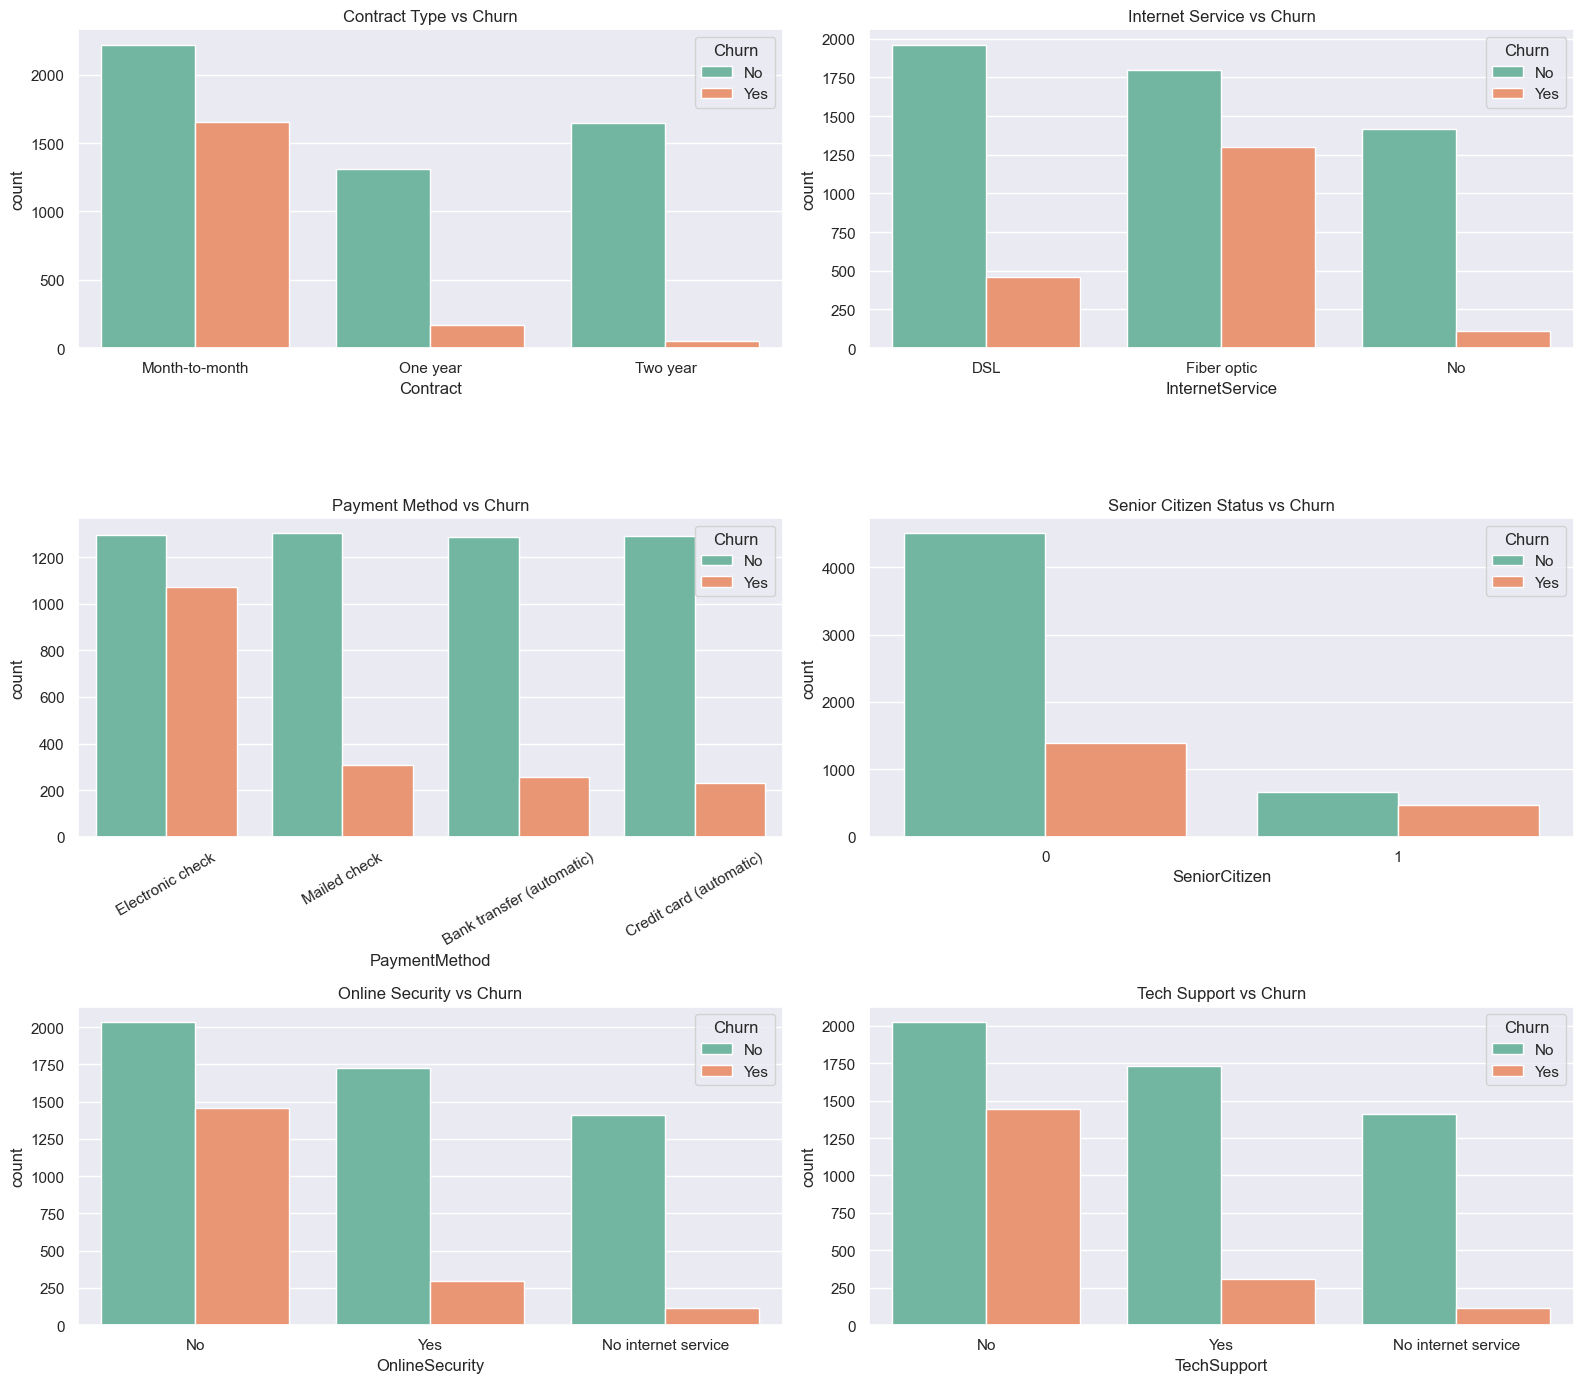

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Contract vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Contract Type vs Churn')

# InternetService vs Churn
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Internet Service vs Churn')

# PaymentMethod vs Churn
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[1, 0], palette='Set2')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].set_title('Payment Method vs Churn')

# SeniorCitizen vs Churn
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Senior Citizen Status vs Churn')

# OnlineSecurity vs Churn
sns.countplot(data=df, x='OnlineSecurity', hue='Churn', ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('Online Security vs Churn')

# TechSupport vs Churn
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[2, 1], palette='Set2')
axes[2, 1].set_title('Tech Support vs Churn')

plt.tight_layout()
plt.show()